# 04 — Group Stage Evaluation

Compares the pre-tournament model predictions against the **actual 2026 FIFA World Cup group stage results** (72 matches, June 11–27).

**Prerequisites:** This notebook uses the original models and predictions files. Run it **before** replacing `data/raw/results.csv` with the updated data.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid', palette='muted')
CLASSES = ['Home Win', 'Away Win', 'Draw']

# Team name map: updated results CSV → normalised names used in predictions.csv
EVAL_NAME_MAP = {
    'South Korea':    'Korea Republic',
    'Czech Republic': 'Czechia',
    'Ivory Coast':    "Côte d'Ivoire",
    'Iran':           'IR Iran',
    'Turkey':         'Türkiye',
    'United States':  'USA',
    'DR Congo':       'Congo DR',
    'Cape Verde':     'Cabo Verde',
}

In [7]:
def load_group_stage_actuals(results_path, name_map):
    """Load 2026 WC group stage results and compute actual outcome."""
    raw = pd.read_csv(results_path, na_values=['NA'])
    wc = raw[
        (raw['tournament'] == 'FIFA World Cup') &
        (raw['date'] >= '2026-06-11') &
        (raw['date'] <= '2026-06-27') &
        (raw['home_score'].notna())
    ].copy()

    wc['home_team'] = wc['home_team'].replace(name_map)
    wc['away_team'] = wc['away_team'].replace(name_map)
    wc['home_score'] = wc['home_score'].astype(int)
    wc['away_score'] = wc['away_score'].astype(int)

    conditions = [
        wc['home_score'] > wc['away_score'],
        wc['home_score'] < wc['away_score'],
        wc['home_score'] == wc['away_score'],
    ]
    wc['actual_outcome'] = np.select(conditions, ['Home Win', 'Away Win', 'Draw'], default='Unknown')
    return wc[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'actual_outcome']]


def load_and_merge(actuals, predictions_path):
    """Merge actuals onto predictions by (date, home_team, away_team)."""
    preds = pd.read_csv(predictions_path)
    preds['date'] = preds['date'].astype(str).str[:10]

    merged = preds.merge(
        actuals,
        on=['date', 'home_team', 'away_team'],
        how='inner',
        validate='1:1',
    )
    assert len(merged) == 72, (
        f"Expected 72 matched rows, got {len(merged)}. "
        f"Unmatched actuals: {set(actuals['home_team']) - set(preds['home_team'])}"
    )
    return merged


actuals = load_group_stage_actuals('../data/updated results/results.csv', EVAL_NAME_MAP)
merged  = load_and_merge(actuals, '../data/processed/predictions.csv')

print(f"Matched {len(merged)} fixtures")
print(f"\nActual outcome distribution:")
print(merged['actual_outcome'].value_counts())

Matched 72 fixtures

Actual outcome distribution:
actual_outcome
Home Win    33
Draw        20
Away Win    19
Name: count, dtype: int64


## 1. Headline Metrics

In [8]:
for name, col in [('Random Forest', 'rf_prediction'), ('Logistic Regression', 'lr_prediction')]:
    y_pred = merged[col]
    y_true = merged['actual_outcome']
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro', labels=CLASSES)
    f1_per = f1_score(y_true, y_pred, average=None, labels=CLASSES)

    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.3f}  ({int(acc*72)}/72 correct)")
    print(f"  F1-macro : {f1_mac:.3f}")
    for cls, f in zip(CLASSES, f1_per):
        print(f"  F1 {cls:<10}: {f:.3f}")
    print(classification_report(y_true, y_pred, labels=CLASSES))


  Random Forest
  Accuracy : 0.431  (31/72 correct)
  F1-macro : 0.420
  F1 Home Win  : 0.500
  F1 Away Win  : 0.400
  F1 Draw      : 0.359
              precision    recall  f1-score   support

    Home Win       0.56      0.45      0.50        33
    Away Win       0.35      0.47      0.40        19
        Draw       0.37      0.35      0.36        20

    accuracy                           0.43        72
   macro avg       0.42      0.43      0.42        72
weighted avg       0.45      0.43      0.43        72


  Logistic Regression
  Accuracy : 0.458  (33/72 correct)
  F1-macro : 0.455
  F1 Home Win  : 0.475
  F1 Away Win  : 0.468
  F1 Draw      : 0.421
              precision    recall  f1-score   support

    Home Win       0.54      0.42      0.47        33
    Away Win       0.39      0.58      0.47        19
        Draw       0.44      0.40      0.42        20

    accuracy                           0.46        72
   macro avg       0.46      0.47      0.45        72
weigh

> **Note:** These figures are lower than the 68.8% / 66.7% historical test-set accuracy. This is expected: World Cup group stages have a higher draw rate and more upsets than a general mixed-tournament holdout, because teams are more evenly matched at this level and tactical caution is common.

## 2. Confusion Matrices

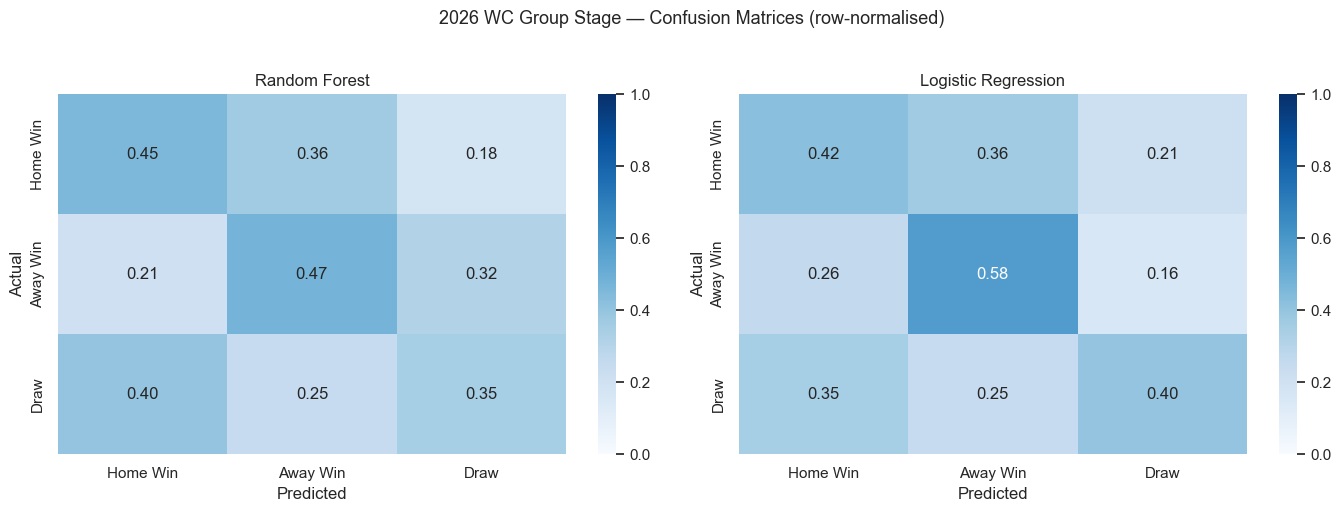

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], 'rf_prediction',  'Random Forest'),
    (axes[1], 'lr_prediction', 'Logistic Regression'),
]:
    cm = confusion_matrix(merged['actual_outcome'], merged[col],
                          labels=CLASSES, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('2026 WC Group Stage — Confusion Matrices (row-normalised)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Per-Class F1 Comparison

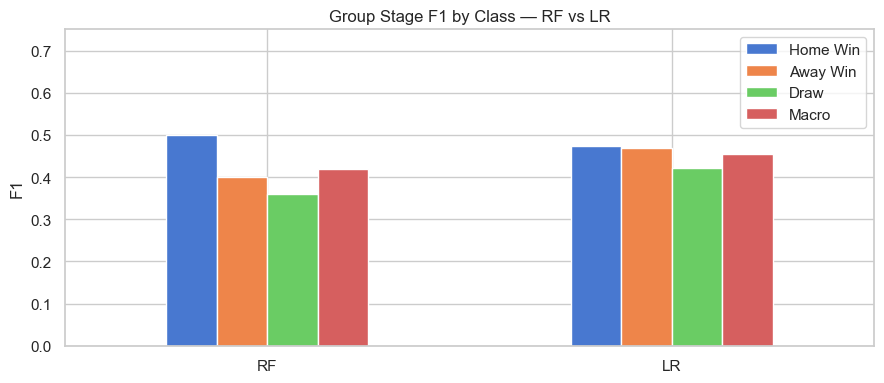

In [10]:
metrics = {}
for name, col in [('RF', 'rf_prediction'), ('LR', 'lr_prediction')]:
    f1s = f1_score(merged['actual_outcome'], merged[col], average=None, labels=CLASSES)
    metrics[name] = dict(zip(CLASSES, f1s))
    metrics[name]['Macro'] = f1_score(merged['actual_outcome'], merged[col], average='macro')

pd.DataFrame(metrics).T.plot(kind='bar', figsize=(9, 4), rot=0, edgecolor='white')
plt.title('Group Stage F1 by Class — RF vs LR')
plt.ylabel('F1'); plt.ylim(0, 0.75); plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. Match-by-Match Results Table

In [11]:
t = merged[['date', 'home_team', 'away_team',
            'home_score', 'away_score', 'actual_outcome',
            'rf_prediction', 'lr_prediction',
            'rf_home_win_prob', 'rf_draw_prob', 'rf_away_win_prob']].copy()

t['RF'] = (t['rf_prediction'] == t['actual_outcome']).map({True: '✓', False: '✗'})
t['LR'] = (t['lr_prediction'] == t['actual_outcome']).map({True: '✓', False: '✗'})
t['score'] = t['home_score'].astype(str) + '-' + t['away_score'].astype(str)
t['rf_confidence'] = t[['rf_home_win_prob', 'rf_draw_prob', 'rf_away_win_prob']].max(axis=1).round(2)

display_cols = ['date', 'home_team', 'away_team', 'score',
                'actual_outcome', 'rf_prediction', 'RF', 'lr_prediction', 'LR', 'rf_confidence']

pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.2f}'.format)
t[display_cols].sort_values('date')

,date,home_team,away_team,score,actual_outcome,rf_prediction,RF,lr_prediction,LR,rf_confidence
0,2026-06-11,Mexico,South Africa,2-0,Home Win,Home Win,✓,Home Win,✓,0.61
1,2026-06-11,Korea Republic,Czechia,2-1,Home Win,Away Win,✗,Away Win,✗,0.50
2,2026-06-12,Canada,Bosnia and Herzegovina,1-1,Draw,Home Win,✗,Home Win,✗,0.46
3,2026-06-12,USA,Paraguay,4-1,Home Win,Away Win,✗,Draw,✗,0.42
4,2026-06-13,Qatar,Switzerland,1-1,Draw,Away Win,✗,Away Win,✗,0.68
5,2026-06-13,Brazil,Morocco,1-1,Draw,Away Win,✗,Away Win,✗,0.54
6,2026-06-13,Haiti,Scotland,0-1,Away Win,Draw,✗,Draw,✗,0.46
7,2026-06-13,Australia,Türkiye,2-0,Home Win,Away Win,✗,Away Win,✗,0.68
11,2026-06-14,Sweden,Tunisia,5-1,Home Win,Away Win,✗,Away Win,✗,0.70
10,2026-06-14,Netherlands,Japan,2-2,Draw,Draw,✓,Draw,✓,0.52


## 5. Upset Detection — Confident Wrong Predictions

In [12]:
CONFIDENCE_THRESHOLD = 0.60

t['rf_max_prob'] = t[['rf_home_win_prob', 'rf_draw_prob', 'rf_away_win_prob']].max(axis=1)

upsets = t[
    (t['RF'] == '✗') & (t['rf_max_prob'] >= CONFIDENCE_THRESHOLD)
].sort_values('rf_max_prob', ascending=False)

print(f"RF was ≥{int(CONFIDENCE_THRESHOLD*100)}% confident but WRONG on {len(upsets)} matches:\n")
upsets[['date', 'home_team', 'away_team', 'score',
         'actual_outcome', 'rf_prediction', 'rf_max_prob']]

RF was ≥60% confident but WRONG on 16 matches:



,date,home_team,away_team,score,actual_outcome,rf_prediction,rf_max_prob
62,2026-06-26,Cabo Verde,Saudi Arabia,0-0,Draw,Away Win,0.84
69,2026-06-27,Congo DR,Uzbekistan,3-1,Home Win,Away Win,0.83
57,2026-06-25,Ecuador,Germany,2-1,Home Win,Away Win,0.77
46,2026-06-23,England,Ghana,0-0,Draw,Home Win,0.76
13,2026-06-15,IR Iran,New Zealand,2-2,Draw,Home Win,0.75
58,2026-06-25,Japan,Sweden,1-1,Draw,Home Win,0.75
52,2026-06-24,Scotland,Brazil,0-3,Away Win,Home Win,0.71
30,2026-06-19,USA,Australia,2-0,Home Win,Away Win,0.71
11,2026-06-14,Sweden,Tunisia,5-1,Home Win,Away Win,0.70
4,2026-06-13,Qatar,Switzerland,1-1,Draw,Away Win,0.68


## 6. Agreement Breakdown

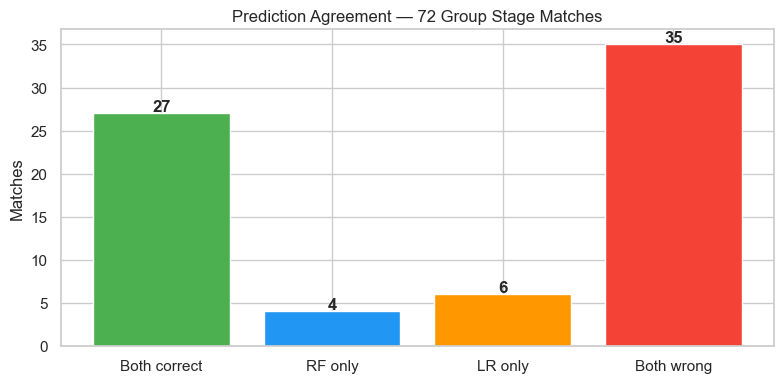

{'Both correct': np.int64(27), 'RF only': np.int64(4), 'LR only': np.int64(6), 'Both wrong': np.int64(35)}


In [13]:
rf_right = merged['rf_prediction'] == merged['actual_outcome']
lr_right = merged['lr_prediction'] == merged['actual_outcome']

counts = {
    'Both correct': ( rf_right &  lr_right).sum(),
    'RF only':      ( rf_right & ~lr_right).sum(),
    'LR only':      (~rf_right &  lr_right).sum(),
    'Both wrong':   (~rf_right & ~lr_right).sum(),
}

colors = ['#4caf50', '#2196f3', '#ff9800', '#f44336']
plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values(), color=colors, edgecolor='white')
for i, (k, v) in enumerate(counts.items()):
    plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.title('Prediction Agreement — 72 Group Stage Matches')
plt.ylabel('Matches')
plt.tight_layout()
plt.show()
print(counts)

## 7. Confidence vs Accuracy

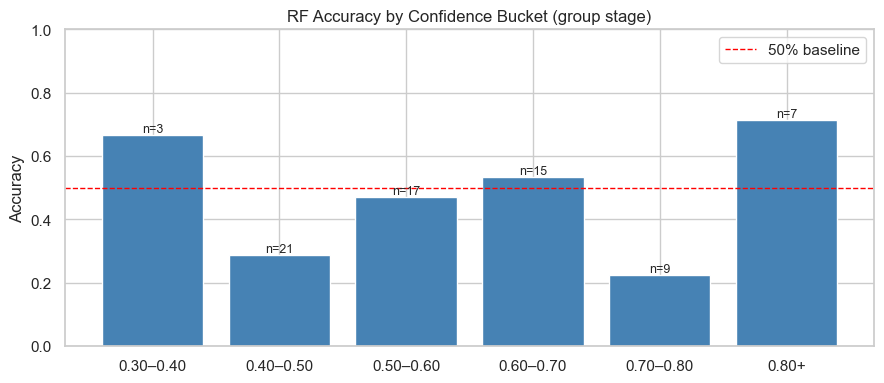

             accuracy  n_matches
prob_bucket                     
0.30–0.40        0.67          3
0.40–0.50        0.29         21
0.50–0.60        0.47         17
0.60–0.70        0.53         15
0.70–0.80        0.22          9
0.80+            0.71          7


In [14]:
merged['rf_max_prob'] = merged[['rf_home_win_prob', 'rf_draw_prob', 'rf_away_win_prob']].max(axis=1)
merged['rf_correct']  = (merged['rf_prediction'] == merged['actual_outcome']).astype(int)

bins   = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.01]
labels = ['0.30–0.40', '0.40–0.50', '0.50–0.60', '0.60–0.70', '0.70–0.80', '0.80+']
merged['prob_bucket'] = pd.cut(merged['rf_max_prob'], bins=bins, labels=labels, right=False)

calibration = merged.groupby('prob_bucket', observed=True)['rf_correct'].agg(['mean', 'count'])
calibration.columns = ['accuracy', 'n_matches']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(calibration.index, calibration['accuracy'], color='steelblue', edgecolor='white')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% baseline')
for i, (idx, row) in enumerate(calibration.iterrows()):
    ax.text(i, row['accuracy'] + 0.01, f"n={int(row['n_matches'])}", ha='center', fontsize=9)
ax.set_title('RF Accuracy by Confidence Bucket (group stage)')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1); ax.legend()
plt.tight_layout()
plt.show()
print(calibration)